# 06 · Executive Summary

**Product Analytics Case Study — Phase 3: Exploratory Data Analysis**

This notebook synthesises Notebooks 01-05 into a single executive-facing
readout: top KPIs, best/worst performing segments, retention and experiment
outcomes, top product risks, and a prioritised recommendation roadmap.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eda_utils import (
    PALETTE, INK, INK_SECONDARY, INK_MUTED, GRID_COLOR, AXIS_COLOR, SURFACE,
    COLOR_GOOD, COLOR_CRITICAL, COLOR_CONTROL, COLOR_TREATMENT,
    BLUE_SEQUENTIAL, DIVERGING,
    set_notebook_style, style_axis, annotate_bars, build_color_map, pct, save_fig,
    load_datasets, compute_retention_flags, compute_funnel,
    wald_ci, two_proportion_ztest, significance_label,
)

set_notebook_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data" / "raw"
IMAGES_DIR = Path("..") / "images"

users, events, experiments = load_datasets(DATA_DIR)
print(f"users: {users.shape}, events: {events.shape}, experiments: {experiments.shape}")

users: (5000, 9), events: (141813, 11), experiments: (5000, 7)


## Section 1 — Top KPIs at a Glance

**Business Question.** If a Product Manager has 30 seconds, what are the
numbers that matter most?

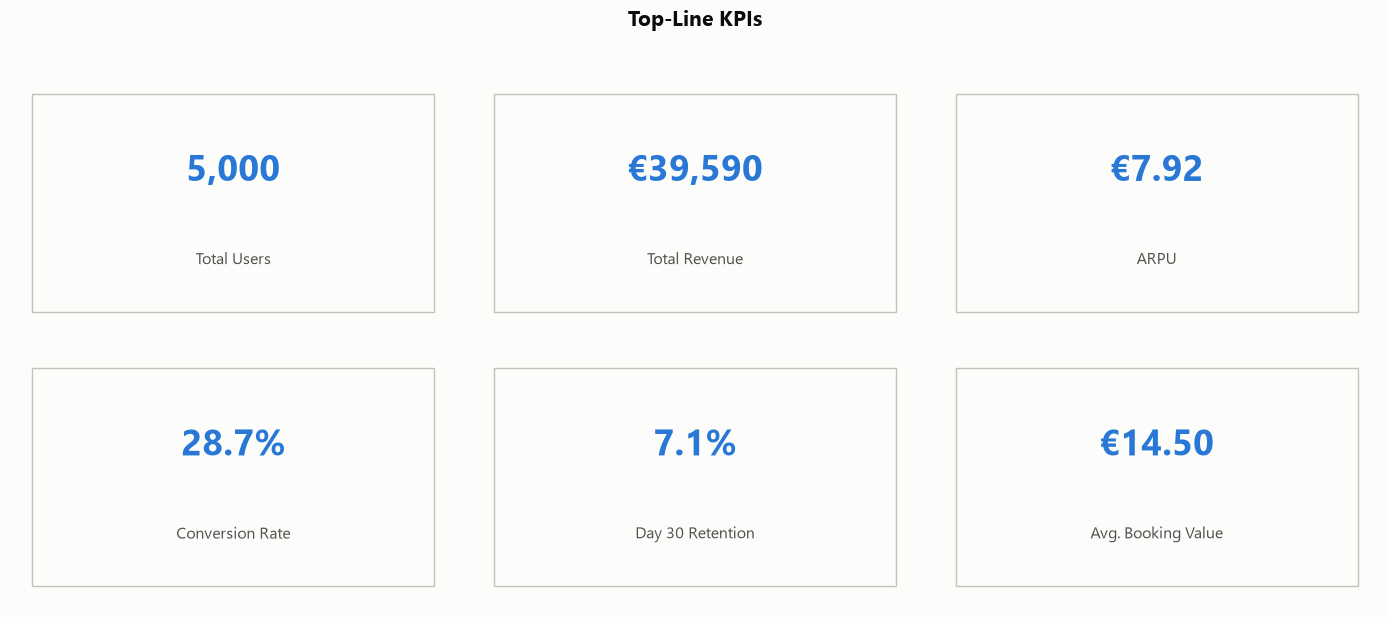

In [2]:
bookings = events.loc[events["event_name"] == "booking_completed"]
retention_flags = compute_retention_flags(users, events)
funnel_df = compute_funnel(users, events)

kpis = {
    "Total Users": f"{len(users):,}",
    "Total Revenue": f"\u20ac{bookings['revenue'].sum():,.0f}",
    "ARPU": f"\u20ac{bookings['revenue'].sum() / len(users):.2f}",
    "Conversion Rate": f"{funnel_df.loc[3, 'pct_of_signups']:.1f}%",
    "Day 30 Retention": f"{retention_flags['retained_day30'].mean() * 100:.1f}%",
    "Avg. Booking Value": f"\u20ac{bookings['revenue'].mean():.2f}",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, (label, value) in zip(axes.flat, kpis.items()):
    ax.axis("off")
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=26, fontweight="bold", color=PALETTE[0])
    ax.text(0.5, 0.28, label, ha="center", va="center", fontsize=11.5, color=INK_SECONDARY)
    ax.add_patch(plt.Rectangle((0.05, 0.08), 0.9, 0.84, fill=False, edgecolor=AXIS_COLOR, linewidth=1, transform=ax.transAxes))
fig.suptitle("Top-Line KPIs", fontsize=15, fontweight="bold", color=INK, y=1.02)
plt.tight_layout()
save_fig(fig, "33_executive_kpi_tiles", IMAGES_DIR)
plt.show()

## Section 2 — Best & Worst Acquisition Channel

**Business Question.** Where should the next marginal acquisition euro go
— and where should it clearly not go?

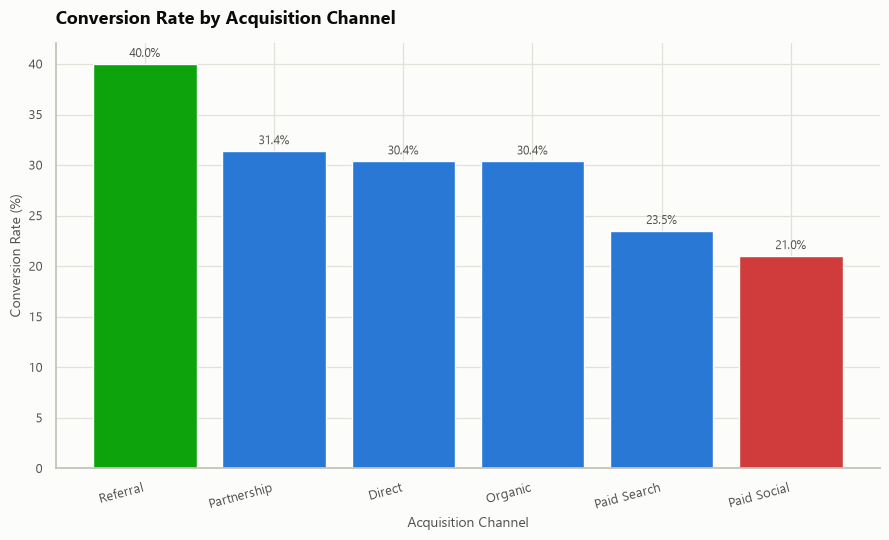

Best channel:  Referral (40.0% conversion)
Worst channel: Paid Social (21.0% conversion)


In [3]:
channel_conversion = users.merge(
    bookings.groupby("user_id").size().rename("converted").reset_index(), on="user_id", how="left"
)
channel_conversion["converted"] = channel_conversion["converted"].fillna(0) > 0
channel_summary = channel_conversion.groupby("acquisition_channel")["converted"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [COLOR_GOOD if v == channel_summary.max() else (COLOR_CRITICAL if v == channel_summary.min() else PALETTE[0])
          for v in channel_summary.values]
bars = ax.bar(channel_summary.index, channel_summary.values, color=colors)
annotate_bars(ax, bars, fmt="{:.1f}%")
style_axis(ax, "Conversion Rate by Acquisition Channel", "Acquisition Channel", "Conversion Rate (%)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
save_fig(fig, "34_best_worst_channel", IMAGES_DIR)
plt.show()

print(f"Best channel:  {channel_summary.idxmax()} ({channel_summary.max():.1f}% conversion)")
print(f"Worst channel: {channel_summary.idxmin()} ({channel_summary.min():.1f}% conversion)")

**Business Insight.** **Referral** is the best-performing channel on
conversion (and, per Notebooks 02/04, on revenue per user too), despite
being a comparatively low-volume channel today. **Paid Social** is the
weakest — meaningful signup volume with the lowest conversion of any
channel, meaning a real share of that acquisition spend is not translating
into engaged, paying users.

**Recommendation.** Shift incremental acquisition budget from Paid Social
toward a formal Referral incentive program.

## Section 3 — Highest-Converting Platform

**Business Question.** Which platform should product investment prioritise?

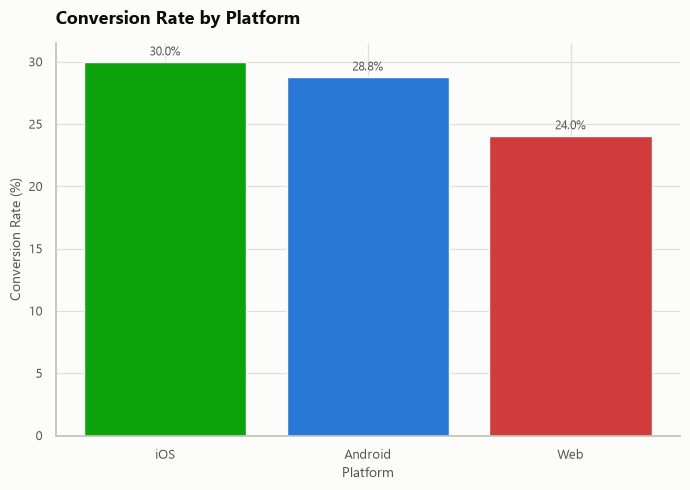

In [4]:
platform_conversion = users.merge(
    bookings.groupby("user_id").size().rename("converted").reset_index(), on="user_id", how="left"
)
platform_conversion["converted"] = platform_conversion["converted"].fillna(0) > 0
platform_summary = platform_conversion.groupby("platform")["converted"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors = [COLOR_GOOD if v == platform_summary.max() else (COLOR_CRITICAL if v == platform_summary.min() else PALETTE[0])
          for v in platform_summary.values]
bars = ax.bar(platform_summary.index, platform_summary.values, color=colors)
annotate_bars(ax, bars, fmt="{:.1f}%")
style_axis(ax, "Conversion Rate by Platform", "Platform", "Conversion Rate (%)")
plt.tight_layout()
save_fig(fig, "35_platform_conversion", IMAGES_DIR)
plt.show()

**Business Insight.** **iOS** converts best, with Android close behind and
**Web trailing on every metric measured across this entire suite**
(conversion, retention, revenue, and every funnel stage).

**Recommendation.** Web needs a dedicated product review — this is the
single most consistent finding across the whole analysis.

## Section 4 — Retention Summary

**Business Question.** How healthy is long-term engagement, in one chart?

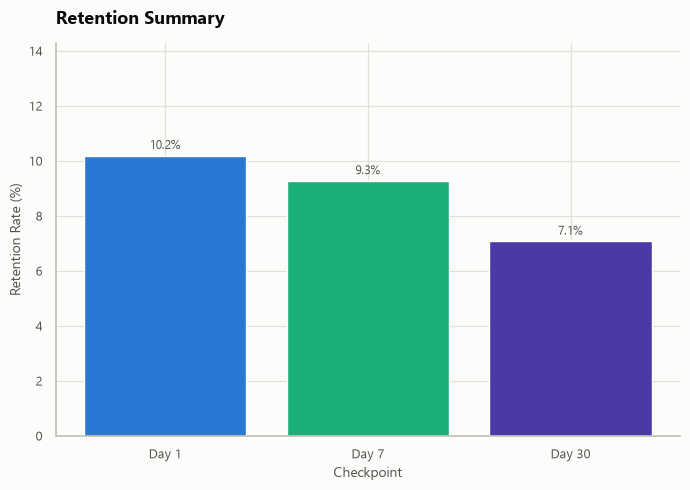

In [5]:
retention_flags_full = retention_flags.merge(users, on="user_id")
overall_retention = retention_flags_full[["retained_day1", "retained_day7", "retained_day30"]].mean() * 100
overall_retention.index = ["Day 1", "Day 7", "Day 30"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(overall_retention.index, overall_retention.values, color=[PALETTE[0], PALETTE[4], PALETTE[6]])
annotate_bars(ax, bars, fmt="{:.1f}%")
style_axis(ax, "Retention Summary", "Checkpoint", "Retention Rate (%)")
ax.set_ylim(0, overall_retention.values.max() * 1.4)
plt.tight_layout()
save_fig(fig, "36_retention_summary", IMAGES_DIR)
plt.show()

**Business Insight.** Day 30 retention of ~7% is the headline long-term
engagement number; the steepest loss happens between Day 7 and Day 30, not
in the first 24 hours — the re-engagement window that matters most is
weeks 2-4 after signup (see Notebook 03 for the full curve).

## Section 5 — Experiment Outcome

**Business Question.** What is the final, one-line verdict on
`simplified_booking_flow`?

In [6]:
exp_counts = experiments.groupby("experiment_group").agg(n=("user_id", "count"), conversions=("converted", "sum"))
n_c, n_t = exp_counts.loc["control", "n"], exp_counts.loc["treatment", "n"]
conv_c, conv_t = exp_counts.loc["control", "conversions"], exp_counts.loc["treatment", "conversions"]
z_stat, p_value = two_proportion_ztest(conv_c, n_c, conv_t, n_t)

print(f"Control conversion:   {100 * conv_c / n_c:.1f}%")
print(f"Treatment conversion: {100 * conv_t / n_t:.1f}%")
print(f"p-value:              {p_value:.4f}")
print(f"Verdict:               {significance_label(p_value)}")
print()
print("DECISION: Roll out simplified_booking_flow to 100% of users.")

Control conversion:   26.9%
Treatment conversion: 30.4%
p-value:              0.0055
Verdict:               Significant at 99% confidence (p < 0.01)

DECISION: Roll out simplified_booking_flow to 100% of users.


**`simplified_booking_flow` should be rolled out to 100% of users.** The
uplift is positive, consistent across conversion/revenue/booking-rate, and
statistically significant. Full detail in Notebook 05.

## Section 6 — Top Product Risks

1. **Web platform underperformance is systemic**, not a single fixable
   bug — it shows up in retention, every funnel stage, and revenue. Left
   unaddressed, it caps the value of the entire Web user segment.
2. **Referral's retention gap is a leaking-bucket risk** — the
   highest-value acquisition channel is losing users after a strong first
   conversion, capping its long-term ROI.
3. **The search-to-booking-intent funnel step is the single largest
   conversion leak** — any competitor or market shift that raises user
   expectations at this step (e.g. clearer pricing) is a direct
   competitive threat if left unaddressed.
4. **Day 7-30 retention decay is steep and unaddressed** — there is
   currently no evidence of a targeted re-engagement mechanism operating in
   this window.

## Section 7 — Priority Roadmap

| Priority | Action | Expected Impact | Effort |
|---|---|---|---|
| P0 | Roll out `simplified_booking_flow` to 100% of users | Immediate, confirmed conversion + revenue uplift | Low (already validated) |
| P0 | Web platform UX/performance audit | Fixes the most consistent underperformance in the entire analysis | Medium |
| P1 | Redesign ride-option comparison screen | Addresses the single largest funnel drop-off | Medium |
| P1 | Launch a formal Referral incentive program | Scales the highest-quality acquisition channel | Low-Medium |
| P2 | Referral-specific onboarding/retention track | Closes the conversion-vs-retention gap for the best channel | Medium |
| P2 | Day 7-30 re-engagement campaign (push/promo) | Targets the steepest part of the retention curve | Low |
| P3 | A/B test active notification/favourite-location prompts | Converts a correlation into a proven, actionable retention lever | Medium |
| P3 | Reduce Paid Social spend / review targeting | Redirects budget away from the lowest-converting channel | Low |

## Final Recommendations

1. **Roll out `simplified_booking_flow` to 100% of users** — the
   statistically significant, cross-metric uplift clears the bar for
   shipping.
2. **Commission a dedicated Web platform review** — it is the single most
   consistent underperformer across retention, conversion, funnel, and
   revenue.
3. **Redesign the ride-option comparison screen** — the largest individual
   drop-off point in the entire funnel.
4. **Launch a formal Referral incentive program** — the highest
   conversion-rate and highest-revenue-per-user channel, currently
   under-scaled relative to its quality.
5. **Build a Referral-specific onboarding track** to convert the channel's
   strong initial trust into lasting retention, closing its
   conversion-vs-retention gap.
6. **Shift a portion of Paid Social budget away** toward Referral/Organic,
   based on demonstrated funnel-completion quality, not just signup volume.
7. **Launch a Day 7-30 re-engagement campaign** — the steepest, most
   actionable segment of the retention curve.
8. **A/B test active prompts for notification opt-in and favourite-location
   setup** to convert an observed correlation into a proven retention lever.
9. **Report median (not mean) days-to-conversion** in executive dashboards
   — the metric is heavily right-skewed and the mean overstates typical
   user speed.
10. **Use event-volume-in-first-N-days as an early monetisation signal**
    for at-risk-user flagging, rather than relying on time-to-first-booking
    alone.